<a href="https://colab.research.google.com/github/manha-star/Computer-Vision-Project/blob/training/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><h1> <b> Object Classification Using YOLO <b> </h1></center>

<h1>YOU NEED TO RUN THIS</h1>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Importing required Libraries

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2
import seaborn as sns
import glob
import xml.etree.ElementTree as ET
from PIL import Image
import os
import shutil

# Dataset Description






Plant Images for Object Classification

available on kaggle => https://www.kaggle.com/datasets/hanselliott/toxic-plant-classification


# Data Preprocessing

For preprocessing:
- We have to convert the dataset into that acceptable by YOLO.
  - Heirarchy of folders should be the one accepted by YOLO
- Check and see if there are any missing images. And remove them from dataset.


## Heirarchy of Folders correction

<h1>YOU DO NOT NEED TO RUN THIS</h1>

Defining paths to train and test folders.

In [ ]:
# train_dir = '/content/drive/MyDrive/project/train/Western_Poison_Oak'
# val_dir = '/content/drive/MyDrive/project/val/Western_Poison_Oak'

# train_dir2 = '/content/drive/MyDrive/project/train/Eastern_Poison_Oak'
# val_dir2 = '/content/drive/MyDrive/project/val/Eastern_Poison_Oak'

# train_dir3 = '/content/drive/MyDrive/project/train/Eastern_Poison_Ivy'
# val_dir3 = '/content/drive/MyDrive/project/val/Eastern_Poison_Ivy'

# train_dir4 = '/content/drive/MyDrive/project/train/Western_Poison_Ivy'
# val_dir4 = '/content/drive/MyDrive/project/val/Western_Poison_Ivy'

# train_dir5 = '/content/drive/MyDrive/project/train/Poison_Sumac'
# val_dir5 = '/content/drive/MyDrive/project/val/Poison_Sumac'

# train_dir6 = '/content/drive/MyDrive/project/train/Virginia_Creeper'
# val_dir6 = '/content/drive/MyDrive/project/val/Virginia_Creeper'

# train_dir7 = '/content/drive/MyDrive/project/train/Boxelder'
# val_dir7 = '/content/drive/MyDrive/project/val/Boxelder'

# train_dir8 = '/content/drive/MyDrive/project/train/Jack_In_The_Pulpit'
# val_dir8 = '/content/drive/MyDrive/project/val/Jack_In_The_Pulpit'

# train_dir9 = '/content/drive/MyDrive/project/train/Bear_Oak'
# val_dir9 = '/content/drive/MyDrive/project/val/Bear_Oak'

# train_dir10 = '/content/drive/MyDrive/project/train/Fragrant_Sumac'
# val_dir10 = '/content/drive/MyDrive/project/val/Fragrant_Sumac'

train_dir = '/content/drive/MyDrive/project/2/train/Western_Poison_Oak'
val_dir = '/content/drive/MyDrive/project/2/val/Western_Poison_Oak'

train_dir2 = '/content/drive/MyDrive/project/2/train/Eastern_Poison_Oak'
val_dir2 = '/content/drive/MyDrive/project/2/val/Eastern_Poison_Oak'

train_dir3 = '/content/drive/MyDrive/project/2/train/Eastern_Poison_Ivy'
val_dir3 = '/content/drive/MyDrive/project/2/val/Eastern_Poison_Ivy'

train_dir4 = '/content/drive/MyDrive/project/2/train/Western_Poison_Ivy'
val_dir4 = '/content/drive/MyDrive/project/2/val/Western_Poison_Ivy'

train_dir5 = '/content/drive/MyDrive/project/2/train/Poison_Sumac'
val_dir5 = '/content/drive/MyDrive/project/2/val/Poison_Sumac'

train_dir6 = '/content/drive/MyDrive/project/2/train/Virginia_Creeper'
val_dir6 = '/content/drive/MyDrive/project/2/val/Virginia_Creeper'

train_dir7 = '/content/drive/MyDrive/project/2/train/Boxelder'
val_dir7 = '/content/drive/MyDrive/project/2/val/Boxelder'

train_dir8 = '/content/drive/MyDrive/project/2/train/Jack_In_The_Pulpit'
val_dir8 = '/content/drive/MyDrive/project/2/val/Jack_In_The_Pulpit'

train_dir9 = '/content/drive/MyDrive/project/2/train/Bear_Oak'
val_dir9 = '/content/drive/MyDrive/project/2/val/Bear_Oak'

train_dir10 = '/content/drive/MyDrive/project/2/train/Fragrant_Sumac'
val_dir10 = '/content/drive/MyDrive/project/2/val/Fragrant_Sumac'



The train and test folders have all the images and labels together.

But for YOLO, the directories should be in:

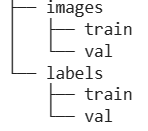


<h1 style="color: red;">ONLY NEEDS TO BE RUN ONCE!</h1>
<h2>YOU DO NOT NEED TO RUN THIS!</h2>
Making directories according to above struture of folders

In [ ]:
#import os
#run it once for making directories

# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Western_Poison_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Eastern_Poison_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Eastern_Poison_Ivy", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Western_Poison_Ivy", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Poison_Sumac", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Virginia_Creeper", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Boxelder", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Jack_In_The_Pulpit", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Bear_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Fragrant_Sumac", exist_ok=True)

# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Western_Poison_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Eastern_Poison_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Eastern_Poison_Ivy", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Western_Poison_Ivy", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Poison_Sumac", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Virginia_Creeper", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Boxelder", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Jack_In_The_Pulpit", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Bear_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Fragrant_Sumac", exist_ok=True)

os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Western_Poison_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Eastern_Poison_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Eastern_Poison_Ivy", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Western_Poison_Ivy", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Poison_Sumac", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Virginia_Creeper", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Boxelder", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Jack_In_The_Pulpit", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Bear_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Fragrant_Sumac", exist_ok=True)

os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Western_Poison_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Eastern_Poison_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Eastern_Poison_Ivy", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Western_Poison_Ivy", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Poison_Sumac", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Virginia_Creeper", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Boxelder", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Jack_In_The_Pulpit", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Bear_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Fragrant_Sumac", exist_ok=True)

<h1>YOU DO NOT NEED TO RUN THIS PART</h1>

In [3]:
#set the paths to images directory
# image_dir="/content/drive/MyDrive/project/Datasets/Final_data/images"

image_dir="/content/drive/MyDrive/project/2/Datasets/Final_data/images"

<h1>ONLY NEEDS TO BE RUN ONCE!</h1>
<h2>YOU DO NOT NEED TO RUN THIS!</h2>
Set Full Training and Validation Folders for all Classes

In [ ]:
#Western Poison Oak
#run it once for copying!
for file in os.listdir(train_dir):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Western_Poison_Oak", new_filename), "JPEG")

for file in os.listdir(val_dir):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Western_Poison_Oak", new_filename), "JPEG")


In [ ]:
#Eastern Poison Oak
for file in os.listdir(train_dir2):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir2, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Eastern_Poison_Oak", new_filename), "JPEG")

for file in os.listdir(val_dir2):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir2, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Eastern_Poison_Oak", new_filename), "JPEG")

In [ ]:
#Eastern_Poison_Ivy
for file in os.listdir(train_dir3):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir3, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Eastern_Poison_Ivy", new_filename), "JPEG")

for file in os.listdir(val_dir3):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir3, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Eastern_Poison_Ivy", new_filename), "JPEG")

In [ ]:
#Western Poison Ivy
for file in os.listdir(train_dir4):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir4, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Western_Poison_Ivy", new_filename), "JPEG")

for file in os.listdir(val_dir4):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir4, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Western_Poison_Ivy", new_filename), "JPEG")

In [ ]:
#Poison_Sumac
for file in os.listdir(train_dir5):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir5, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Poison_Sumac", new_filename), "JPEG")

for file in os.listdir(val_dir5):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir5, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Poison_Sumac", new_filename), "JPEG")

In [ ]:
#Virginia_Creeper
for file in os.listdir(train_dir6):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir6, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Virginia_Creeper", new_filename), "JPEG")

for file in os.listdir(val_dir6):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir6, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Virginia_Creeper", new_filename), "JPEG")

In [ ]:
#Boxelder
for file in os.listdir(train_dir7):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir7, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Boxelder", new_filename), "JPEG")

for file in os.listdir(val_dir7):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir7, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Boxelder", new_filename), "JPEG")

In [ ]:
#Jack_In_The_Pulpit
for file in os.listdir(train_dir8):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir8, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Jack_In_The_Pulpit", new_filename), "JPEG")

for file in os.listdir(val_dir8):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir8, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Jack_In_The_Pulpit", new_filename), "JPEG")

In [ ]:
#Bear_Oak
for file in os.listdir(train_dir9):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir9, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Bear_Oak", new_filename), "JPEG")

for file in os.listdir(val_dir9):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir9, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Bear_Oak", new_filename), "JPEG")

In [ ]:
#Fragrant_Sumac
for file in os.listdir(train_dir10):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir10, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Fragrant_Sumac", new_filename), "JPEG")

for file in os.listdir(val_dir10):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir10, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Fragrant_Sumac", new_filename), "JPEG")

Visualizing somme pictures from the dataset

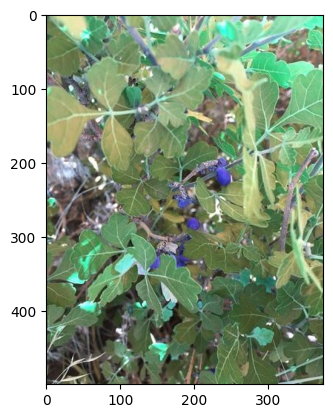

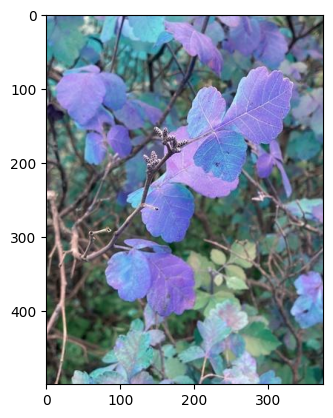

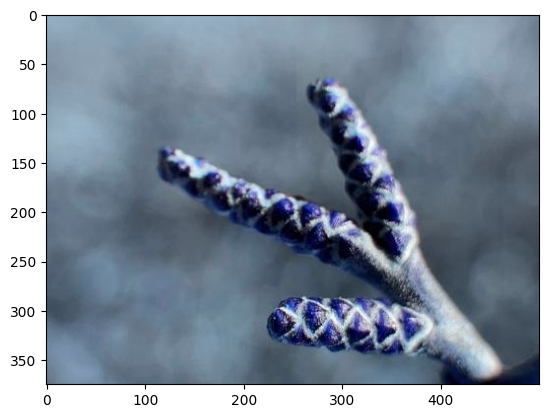

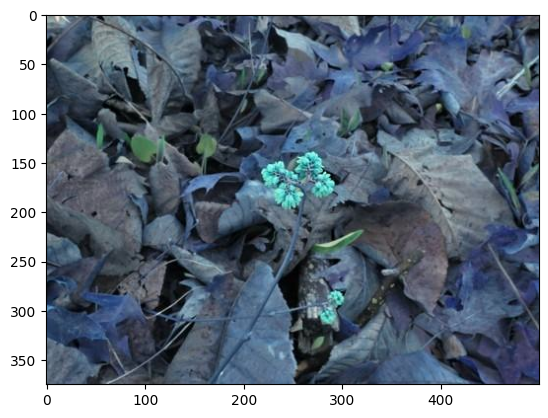

In [ ]:
#visualize first four sample images from train data
for idx, image in enumerate(os.listdir(os.path.join(image_dir, "train/Fragrant_Sumac"))):
    img = cv2.imread(os.path.join(image_dir,"train/Fragrant_Sumac", image), 1)
    plt.imshow(img)
    plt.show()

    if idx == 3:
        break

First install and import

In [5]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.91 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


In [6]:
from ultralytics import YOLO

## Training YOLO

Do not train this model

In [ ]:
model = YOLO('yolov8s-cls.pt') # pretrained model

In [ ]:
model.train(data="/content/drive/MyDrive/project/2/Datasets/Final_data/images",
            epochs=100,
            patience=20,
            batch=8,
            lr0=0.0005,
            imgsz=640,
            weight_decay=0.0005,
            erasing=0.2,
            momentum=0.9,
            dropout=0,
            optimizer="AdamW",
            project="/content/drive/MyDrive/project/2/custom_folder_Eric")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/project/2/Datasets/Final_data/images, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train-33, nbs=64, nms=False, opset=None, optimize=False, optimizer=Ad

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79f667f949b0>
curves: []
curves_results: []
fitness: 0.8687500059604645
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7583333253860474, 'metrics/accuracy_top5': 0.9791666865348816, 'fitness': 0.8687500059604645}
save_dir: PosixPath('/content/drive/.shortcut-targets-by-id/1myGAwIqZwqTsgEHWZAoIMKAsqpzHdm_O/project/2/custom_folder_Eric/train-33')
speed: {'preprocess': 0.6054192958307189, 'inference': 3.9543005124983206, 'loss': 0.0009695583268391297, 'postprocess': 0.001344233332171522}
top1: 0.7583333253860474
top5: 0.9791666865348816

<h1>TRAIN WITH CURRMODEL</h1>

In [ ]:
model2 = YOLO('yolov8s-cls.pt') # pretrained model

In [ ]:
model2.train(data="/content/drive/MyDrive/project/2/Datasets/Final_data/images",
            epochs=100,
            patience=10,
            batch=8,
            lr0=0.0005,
            imgsz=640,
            weight_decay=0.0005,
            erasing=0.2,
            momentum=0.9,
            dropout=0,
            optimizer="AdamW",
            project="/content/drive/MyDrive/project/2/custom_folder_Eric")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/project/2/Datasets/Final_data/images, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.6, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train-39, nbs=64, nms=False, opset=None, optimize=False, optimizer=Ad

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79f61c1cce00>
curves: []
curves_results: []
fitness: 0.8916666805744171
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8041666746139526, 'metrics/accuracy_top5': 0.9791666865348816, 'fitness': 0.8916666805744171}
save_dir: PosixPath('/content/drive/.shortcut-targets-by-id/1myGAwIqZwqTsgEHWZAoIMKAsqpzHdm_O/project/2/custom_folder_Eric/train-39')
speed: {'preprocess': 1.4428133124946878, 'inference': 2.9652136666660076, 'loss': 0.0010921833298501344, 'postprocess': 0.0030771750004987553}
top1: 0.8041666746139526
top5: 0.9791666865348816

In [ ]:
model3 = YOLO('yolov8s-cls.pt') # pretrained model

In [ ]:
model3.train(data="/content/drive/MyDrive/project/2/Datasets/Final_data/images",
            epochs=100,
            patience=10,
            batch=8,
            lr0=0.0005,
            imgsz=640,
            weight_decay=0.0005,
            erasing=0.2,
            momentum=0.9,
            dropout=0,
            optimizer="AdamW",
            project="/content/drive/MyDrive/project/2/custom_folder_Eric")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/project/2/Datasets/Final_data/images, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train-34, nbs=64, nms=False, opset=None, optimize=False, optimizer=Ad

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78366a1bc680>
curves: []
curves_results: []
fitness: 0.8770833313465118
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7749999761581421, 'metrics/accuracy_top5': 0.9791666865348816, 'fitness': 0.8770833313465118}
save_dir: PosixPath('/content/drive/.shortcut-targets-by-id/1myGAwIqZwqTsgEHWZAoIMKAsqpzHdm_O/project/2/custom_folder_Eric/train-34')
speed: {'preprocess': 0.6192794249955114, 'inference': 4.015536420843091, 'loss': 0.0015817625201937822, 'postprocess': 0.0022025916526520937}
top1: 0.7749999761581421
top5: 0.9791666865348816

In [ ]:
model4 = YOLO('yolov8s-cls.pt') # pretrained model

In [ ]:
model4.train(data="/content/drive/MyDrive/project/2/Datasets/Final_data/images",
            epochs=100,
            patience=10,
            batch=8,
            lr0=0.0005,
            imgsz=640,
            weight_decay=0.0005,
            erasing=0.2,
            momentum=0.9,
            dropout=0,
            optimizer="AdamW",
            project="/content/drive/MyDrive/project/2/custom_folder_Eric")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/project/2/Datasets/Final_data/images, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train-34, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7836622ea5d0>
curves: []
curves_results: []
fitness: 0.8479166924953461
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7208333611488342, 'metrics/accuracy_top5': 0.9750000238418579, 'fitness': 0.8479166924953461}
save_dir: PosixPath('/content/drive/.shortcut-targets-by-id/1myGAwIqZwqTsgEHWZAoIMKAsqpzHdm_O/project/2/custom_folder_Eric/train-34')
speed: {'preprocess': 0.9250381166755991, 'inference': 3.3357345333418684, 'loss': 0.0010284499997699945, 'postprocess': 0.0017837333378641538}
top1: 0.7208333611488342
top5: 0.9750000238418579

Please look at [Yolo train Docs](https://docs.ultralytics.com/modes/train/#train-settings) for hyperparameters for model tuning and configuration, e.g. lr0, imgsz, model etc.

## Evaluation Metrics

[This](https://docs.ultralytics.com/guides/yolo-performance-metrics/) is a very good detailed explanation of different perfromance metrics in YOLO.

**Choosing the Right Metrics**

Choosing the right metrics to evaluate often depends on the specific application.

- mAP: Suitable for a broad assessment of model performance.

- IoU: Essential when precise object location is crucial.

- Precision: Important when minimizing false detections is a priority.

- Recall: Vital when it's important to detect every instance of an object.

- F1 Score: Useful when a balance between precision and recall is needed.


In [7]:
currmodel = YOLO('/content/drive/MyDrive/project/2/custom_folder_Manha/actualfinal/weight_decay0.0001/weights/best.pt')

In [8]:
# metrics = bestmodel.val(split="test", project="/content/drive/MyDrive/project/2/custom_folder_Eric")
metrics = currmodel.val(split="test", project="/content/drive/MyDrive/project/2/custom_folder_Manha")

print(metrics.top1)
print(metrics.summary())

Ultralytics 8.4.91 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-cls summary (fused): 30 layers, 5,088,010 parameters, 0 gradients, 12.5 GFLOPs
train: /content/drive/.shortcut-targets-by-id/1myGAwIqZwqTsgEHWZAoIMKAsqpzHdm_O/project/2/Datasets/Final_data/images/train... found 2040 images in 10 classes ✅ 
val: /content/drive/.shortcut-targets-by-id/1myGAwIqZwqTsgEHWZAoIMKAsqpzHdm_O/project/2/Datasets/Final_data/images/val... found 240 images in 10 classes ✅ 
test: /content/drive/.shortcut-targets-by-id/1myGAwIqZwqTsgEHWZAoIMKAsqpzHdm_O/project/2/Datasets/Final_data/images/test... found 120 images in 10 classes ✅ 
WARNING ⚠️ test: Slow image access detected (ping: 0.8±0.3 ms, read: 0.2±0.2 MB/s, size: 156.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
test: Scanning /content/drive/.shortcut-targets-by-id/1myGAwIqZwqTsgEHWZAoIMKAsqpzHdm_O/project/2/Datasets/Final_data/

Showing confusion matrix, that is already stored in detect/train folder

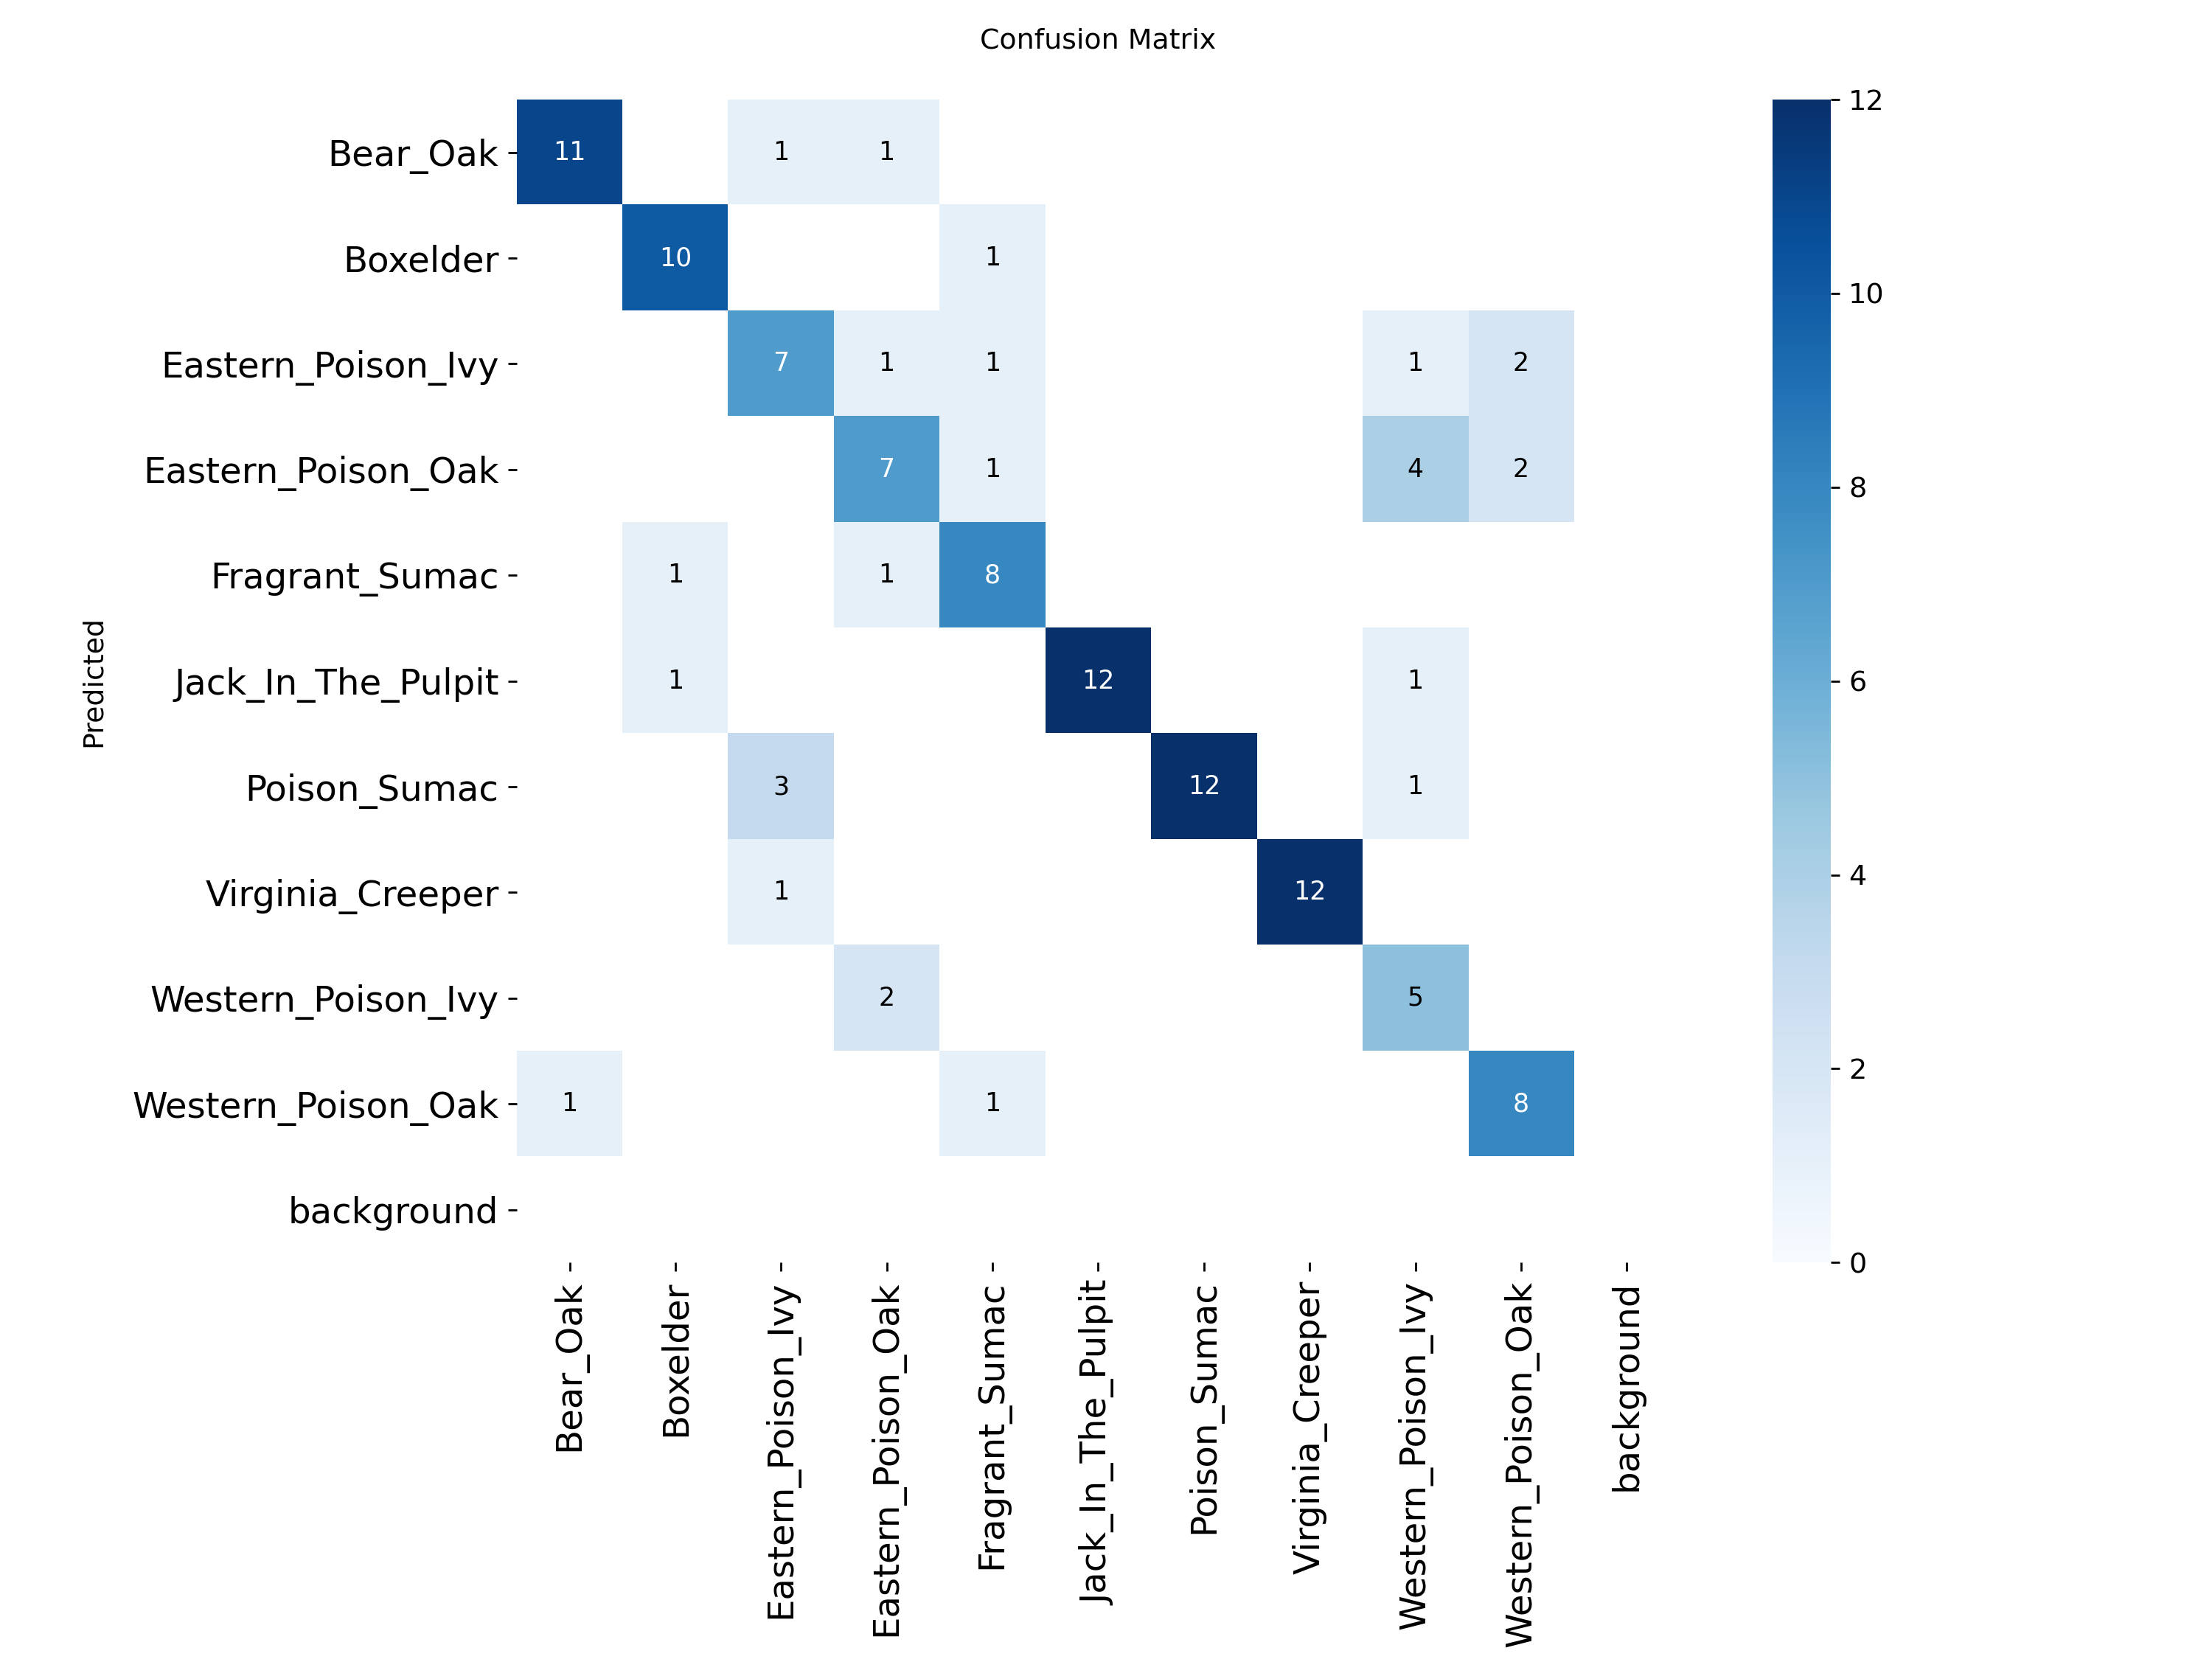

In [10]:
%matplotlib inline
from PIL import Image

Image.open('/content/drive/MyDrive/project/2/custom_folder_Manha/val/confusion_matrix.png')

<h1> Visualization </h1>

In [14]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install opencv-python

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

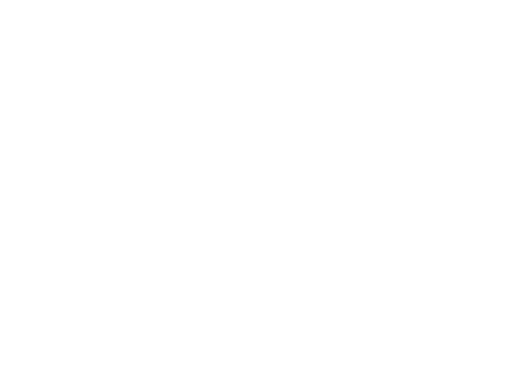

In [19]:
plt.grid(False)      # Disables the grid lines
plt.axis('off')

In [25]:
cm = metrics.confusion_matrix.matrix.astype(np.float64)
print(cm)


# Separate YOLO's background values from the predicted fungi labels
species_matrix_array = cm[:-1, :-1]
bg_false_negatives = cm[:-1, -1]
bg_false_positives = cm[-1, :-1]

# calculate metrics
TP = np.diag(species_matrix_array)
FP = (species_matrix_array.sum(1) - TP) + bg_false_positives
FN = (species_matrix_array.sum(0) - TP) + bg_false_negatives

precision = TP / (TP + FP + 1e-9)
recall = TP / (TP + FN + 1e-9)
F1 = 2 * precision * recall / (precision + recall + 1e-9)

precision_overall = np.mean(precision)
recall_overall = np.mean(recall)
F1_overall = np.mean(F1)

[[         11           0           1           1           0           0           0           0           0           0           0]
 [          0          10           0           0           1           0           0           0           0           0           0]
 [          0           0           7           1           1           0           0           0           1           2           0]
 [          0           0           0           7           1           0           0           0           4           2           0]
 [          0           1           0           1           8           0           0           0           0           0           0]
 [          0           1           0           0           0          12           0           0           1           0           0]
 [          0           0           3           0           0           0          12           0           1           0           0]
 [          0           0           1           0      

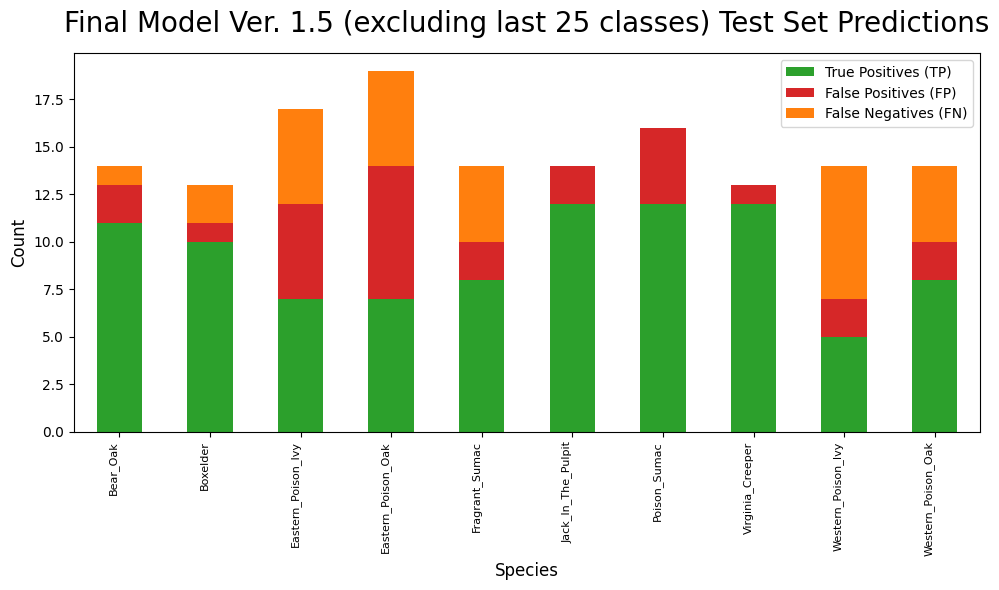

In [27]:
# gather labels
class_names = list(currmodel.names.values())

# create df using prediction values
metrics_df = pd.DataFrame({
    'Class': class_names,
    'True Positives (TP)': TP,
    'False Positives (FP)': FP,
    'False Negatives (FN)': FN,
})

# figure (adjust size as needed) + axes
fig, ax = plt.subplots(figsize=(10, 6))

# bar plot + styling (adjust style as needed)
metrics_df.plot(kind="bar", stacked=True, ax=ax, color=["#2ca02c", "#d62728", "#ff7f0e"])

ax.set_title("Final Model Ver. 1.5 (excluding last 25 classes) Test Set Predictions", fontsize=20, pad=15)
ax.set_xlabel("Species", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticklabels(class_names, fontsize=8, rotation=90, ha="right")

plt.tight_layout()

# save and download the img (change name to organize)
fig.savefig("1.5_last25cut_test_prediction_breakdown.png", dpi=300)